In [1]:
from sklearn.datasets import fetch_openml
import numpy as np  
import pandas as pd 
import matplotlib as mpl
import matplotlib.pyplot as plt 

mnist = fetch_openml('mnist_784')
print(mnist.keys())

X = mnist['data']
y = mnist['target']
print(X.shape)
print(y.shape)


dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])
(70000, 784)
(70000,)


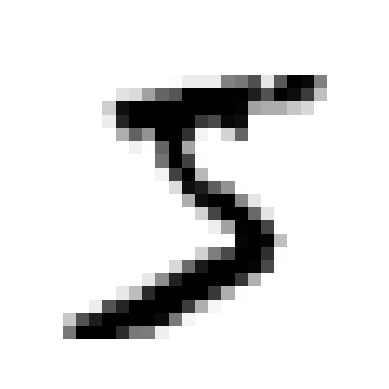

In [2]:

some_digit = X.iloc[0]
some_digit_image = some_digit.to_numpy().reshape(28,28)
plt.imshow(some_digit_image,cmap = 'binary')
plt.axis("off")
plt.show()

In [3]:
%matplotlib inline

In [4]:
y = y.astype(np.uint8)

In [5]:
X_train,X_test = X[:60000],X[60000:]
y_train,y_test =  y[:60000],y[60000:]

## Traning a Binary Classifier

In [6]:
y_train_5 = (y_train == 5)   # True for all 5s, false for all other digits.
y_test_5 = (y_test == 5)

In [10]:
from sklearn.linear_model import SGDClassifier
sgd_clf = SGDClassifier(random_state = 42)
sgd_clf.fit(X_train,y_train_5)
sgd_clf.predict([some_digit])

/mnt/Machine-Learning/.env/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([ True])

In [11]:
from sklearn.model_selection import cross_val_score
cvs = cross_val_score(sgd_clf,X_train,y_train_5,cv = 3 ,scoring = "accuracy")
cvs

array([0.95035, 0.96035, 0.9604 ])

In [12]:
# print(np.bincount(y_train_5.astype(int)))

In [13]:
# X.min().value_counts
# type(X)

## Performance Measures 

## Confusion Matrix


In [14]:
from sklearn.model_selection import cross_val_predict



In [15]:
y_train_predict = cross_val_predict(sgd_clf,X_train,y_train_5,cv = 3)
y_train_predict


array([ True, False, False, ...,  True, False, False], shape=(60000,))

In [16]:
from sklearn.metrics import confusion_matrix


In [17]:
cm = confusion_matrix(y_train_5,y_train_predict)
cm

array([[53892,   687],
       [ 1891,  3530]])

## Precision and Recall

In [18]:
from sklearn.metrics import precision_score , recall_score

In [19]:
pscore = precision_score(y_train_5,y_train_predict)
pscore

0.8370879772350012

In [20]:
rscore= recall_score(y_train_5,y_train_predict)
rscore

0.6511713705958311

## F1 Score

In [21]:
from sklearn.metrics import f1_score

In [22]:
fscore = f1_score(y_train_5,y_train_predict)
fscore

0.7325171197343847

## Trade-Off

In [23]:
y_score = cross_val_predict(sgd_clf , X_train,y_train_5,cv = 3 ,method="decision_function")

In [24]:
from sklearn.metrics import precision_recall_curve


precisions,recalls,tresholds = precision_recall_curve(y_train_5,y_score)

In [25]:
def plot_p_r_curve(precisions,recalls,tresholds):
    plt.plot(tresholds,precisions[:-1],"b--",label = "Precision")
    plt.plot(tresholds,recalls[:-1],"g-",label = "Recall")
    


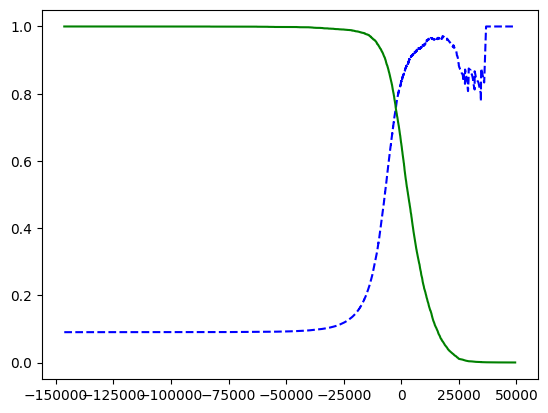

In [26]:
plot_p_r_curve(precisions,recalls,tresholds)
plt.show()

In [27]:
tresholds_90_p = tresholds[np.argmax(precisions >= 0.90)]
print(tresholds_90_p)

3370.0194991439557


In [28]:
y_train_pred90 = (y_score>= tresholds_90_p)

In [29]:
precision_score(y_train_5,y_train_pred90)

0.9000345901072293

In [30]:
recall_score(y_train_5,y_train_pred90)

0.4799852425751706

## ROC Curve

In [31]:
from sklearn.metrics import  roc_curve

fpr , tpr , thresholds = roc_curve(y_train_5,y_score)

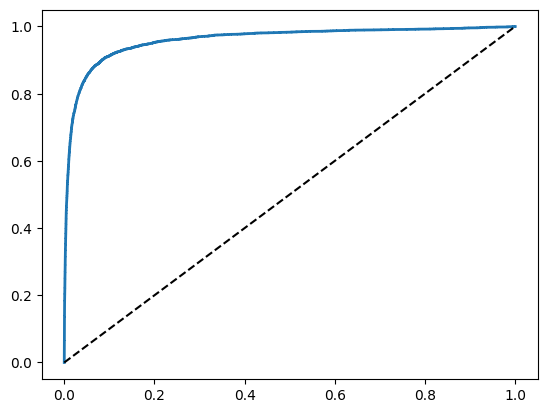

In [32]:
def plot_roc_curve(fpr,tpr,label):
    plt.plot(fpr,tpr,linewidth = 2,label = label)
    plt.plot([0,1],[0,1],"k--")

plot_roc_curve(fpr,tpr,label=None)
plt.show()


In [33]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(random_state = 42)
y_probas_forest  = cross_val_predict(forest_clf , X_train,y_train_5,cv = 3,method="predict_proba")
y_score_f = y_probas_forest[:,1]

In [34]:
fprf,tprf,therf = roc_curve(y_train_5,y_score_f)

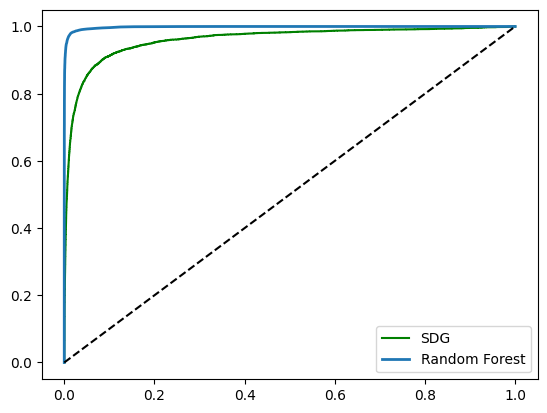

In [35]:
plt.plot(fpr,tpr,"g-",label = "SDG")
plot_roc_curve(fprf,tprf,"Random Forest")
plt.legend(loc = "lower right")
plt.show()

In [36]:
# from sklearn.metrics import roc_auc_score
# roc_auc_score(y_test_5,y_score_f)

## MltiClass Classification

In [44]:
from sklearn.svm import SVC

svm_clf = SVC()
svm_clf.fit(X_train,y_train)  #[it will train N*(N-1)/2 classifires]


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [45]:
svm_clf.predict([some_digit])

/mnt/Machine-Learning/.env/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


array([5], dtype=uint8)

In [46]:
somedigit_score = svm_clf.decision_function([some_digit])
somedigit_score

/mnt/Machine-Learning/.env/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


array([[ 1.72501977,  2.72809088,  7.2510018 ,  8.3076379 , -0.31087254,
         9.3132482 ,  1.70975103,  2.76765202,  6.23049537,  4.84771048]])

In [47]:
np.argmax(somedigit_score)

np.int64(5)

In [48]:
svm_clf.classes_    #[list of target classes]

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [49]:
svm_clf.classes_[5]

np.uint8(5)

In [50]:
from sklearn.multiclass import OneVsRestClassifier
ovr_clf = OneVsRestClassifier(SVC()) #it will train N*(N-1)/2 classifires]
ovr_clf.fit(X_train,y_train)





,estimator,SVC()
,n_jobs,None
,verbose,0
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001


In [51]:
ovr_clf.predict([some_digit])


/mnt/Machine-Learning/.env/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/mnt/Machine-Learning/.env/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/mnt/Machine-Learning/.env/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/mnt/Machine-Learning/.env/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/mnt/Machine-Learning/.env/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/mnt/Machine-Learning/.en

array([5], dtype=uint8)

In [52]:
len(ovr_clf.estimators_)

10

In [53]:
sgd_clf.fit(X_train,y_train)
sgd_clf.predict([some_digit])


/mnt/Machine-Learning/.env/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([3], dtype=uint8)

In [54]:
sgd_clf.decision_function([some_digit])

/mnt/Machine-Learning/.env/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([[-31893.03095419, -34419.69069632,  -9530.63950739,
          1823.73154031, -22320.14822878,  -1385.80478895,
        -26188.91070951, -16147.51323997,  -4604.35491274,
        -12050.767298  ]])

In [37]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf,X_train,y_train,cv=3,scoring = "accuracy")

array([0.87365, 0.85835, 0.8689 ])